# 3. Visualise PyNNLF Output: ASHD 148hh Forecast Horizons

Visualises ASHD 148hh model performance across the three horizons.

## 1. Setup And Paths

In [1]:
from pathlib import Path
import sys

def find_publication_project(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "specs").exists() and (candidate / "data").exists() and (candidate / "results").exists():
            return candidate
    raise FileNotFoundError("Could not find publication/journal_article_1 from the current working directory.")

def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "pynnlf").exists():
            return candidate
    raise FileNotFoundError("Could not find the PyNNLF repo root.")
PROJECT_DIR = find_publication_project()
REPO_ROOT = find_repo_root(PROJECT_DIR)
print(f"Publication project: {PROJECT_DIR}")
print(f"Repository root: {REPO_ROOT}")
import pandas as pd
import matplotlib.pyplot as plt
RESULTS_DIR = PROJECT_DIR / "results" / "02_ashd_148hh_forecast_horizon"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_ORDER = ['m1_naive_hp1', 'm2_snaive_hp2', 'm3_ets_hp1', 'm4_arima_hp1', 'm6_lr_hp1', 'm7_ann_hp1', 'm8_dnn_hp1', 'm9_rt_hp3', 'm10_rf_hp1', 'm13_lstm_hp2', 'm16_prophet_hp1', 'm17_xgb_hp1']
HORIZON_LABELS = {"30_min": "30 minutes", "1_day": "1 day", "1_week": "1 week"}
COLORS = {"30_min": "#2f5597", "1_day": "#70ad47", "1_week": "#c55a11"}
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "axes.grid": True, "grid.alpha": 0.25})
def save_figure(fig, filename):
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")

Publication project: <local path redacted>
Repository root: <local path redacted>


## 2. Load Processed Horizon Tables

In [2]:
required_files = {"ashd_nrmse": RESULTS_DIR / "ashd_148hh_weather_nrmse_by_horizon.csv", "ashd_stddev": RESULTS_DIR / "ashd_148hh_weather_nrmse_stddev_by_horizon.csv", "combined_recap": RESULTS_DIR / "ashd_148hh_horizon_combined_recap.csv"}
missing = [str(path) for path in required_files.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing processed result files. Run notebook 2 first. " + str(missing))
ashd_nrmse = pd.read_csv(required_files["ashd_nrmse"], index_col=0).reindex(MODEL_ORDER)
ashd_stddev = pd.read_csv(required_files["ashd_stddev"], index_col=0).reindex(MODEL_ORDER)
combined_recap = pd.read_csv(required_files["combined_recap"])
display(ashd_nrmse.round(3))

,30_min,1_day,1_week
model_hp,,,
m1_naive_hp1,4.225,9.091,10.937
m2_snaive_hp2,10.946,10.953,10.937
m3_ets_hp1,4.147,9.142,10.981
m4_arima_hp1,3.557,16.179,17.847
m6_lr_hp1,2.657,7.763,8.757
m7_ann_hp1,6.531,8.150,8.836
m8_dnn_hp1,4.138,7.690,8.578
m9_rt_hp3,7.451,10.122,10.445
m10_rf_hp1,4.967,8.490,8.995


## 3. nRMSE By Forecast Horizon

Saved: <local path redacted>


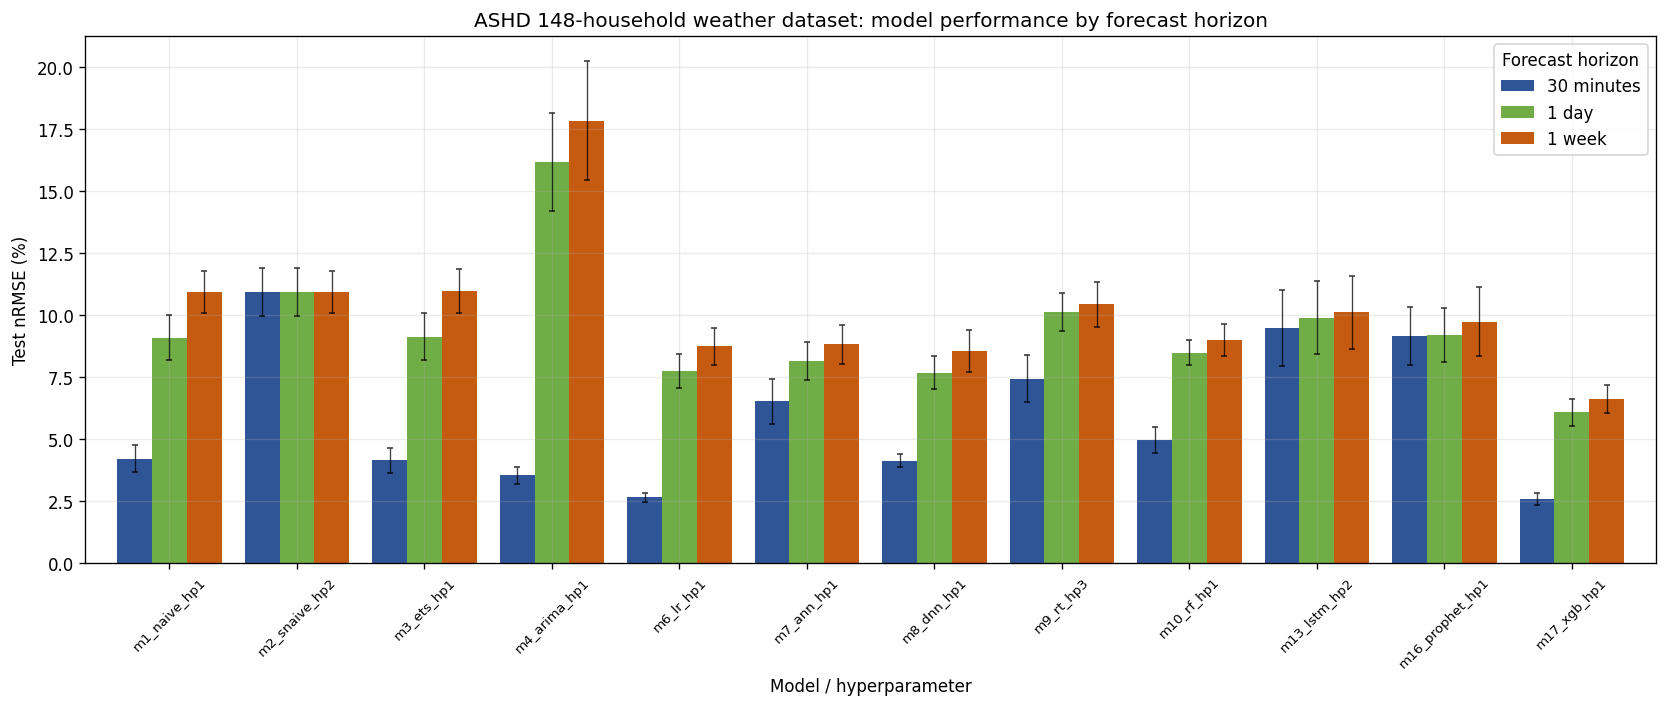

In [3]:
plot_nrmse = ashd_nrmse.rename(columns=HORIZON_LABELS)
plot_stddev = ashd_stddev.rename(columns=HORIZON_LABELS)
fig, ax = plt.subplots(figsize=(14, 6))
plot_nrmse.plot(kind="bar", yerr=plot_stddev, ax=ax, width=0.82, capsize=2, color=[COLORS[column] for column in ashd_nrmse.columns], error_kw={"elinewidth": 0.8, "alpha": 0.75})
ax.set_ylabel("Test nRMSE (%)")
ax.set_xlabel("Model / hyperparameter")
ax.set_title("ASHD 148-household weather dataset: model performance by forecast horizon")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.legend(title="Forecast horizon")
fig.tight_layout()
save_figure(fig, "fig01_ashd_nrmse_by_horizon.png")
plt.show()

## 4. nRMSE Standard Deviation By Forecast Horizon

Saved: <local path redacted>


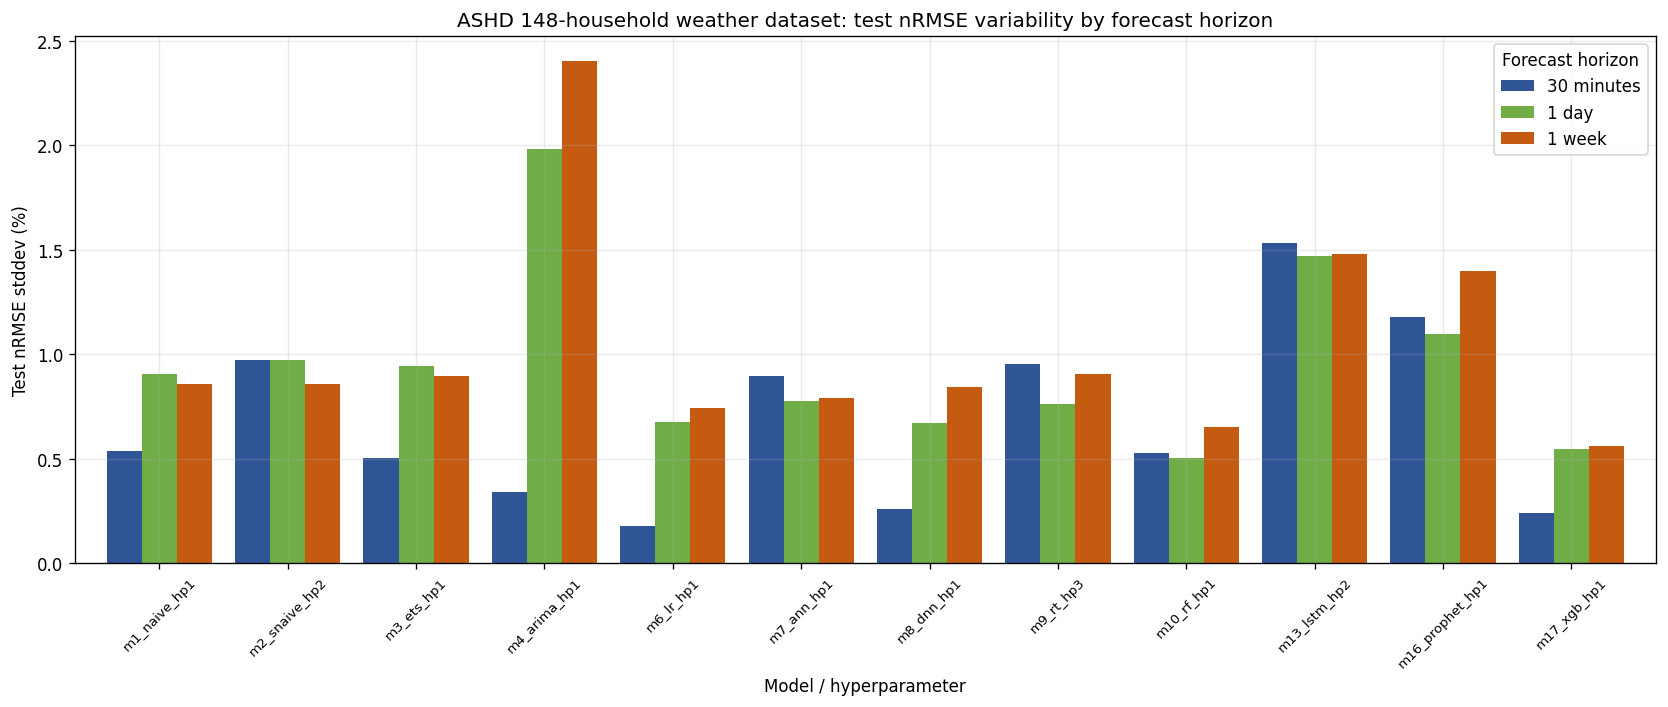

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
plot_stddev.plot(kind="bar", ax=ax, width=0.82, color=[COLORS[column] for column in ashd_stddev.columns])
ax.set_ylabel("Test nRMSE stddev (%)")
ax.set_xlabel("Model / hyperparameter")
ax.set_title("ASHD 148-household weather dataset: test nRMSE variability by forecast horizon")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.legend(title="Forecast horizon")
fig.tight_layout()
save_figure(fig, "fig02_ashd_nrmse_stddev_by_horizon.png")
plt.show()

## 5. Best Model By Horizon

,horizon,best_model_hp,test_nRMSE,test_nRMSE_stddev
0,30 minutes,m17_xgb_hp1,2.612,0.243
1,1 day,m17_xgb_hp1,6.087,0.546
2,1 week,m17_xgb_hp1,6.611,0.560


Saved: <local path redacted>


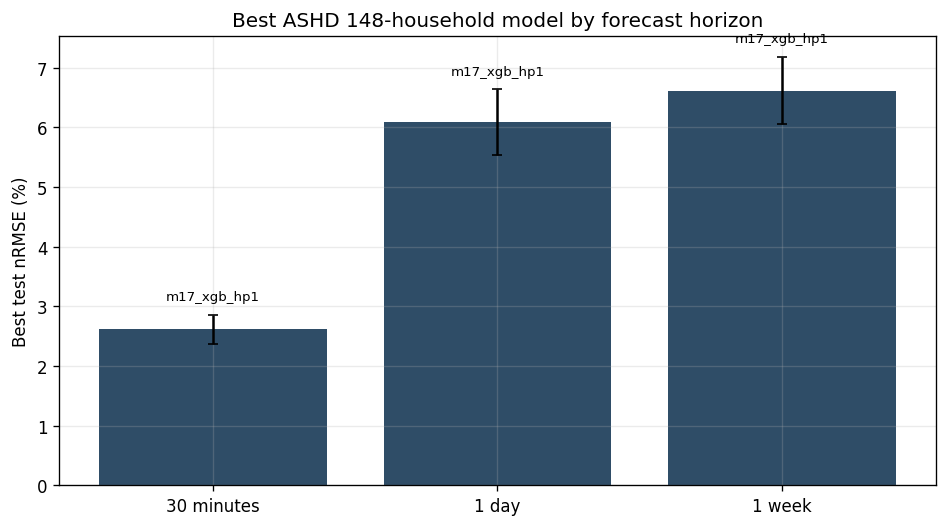

In [5]:
best_rows = []
for horizon in ashd_nrmse.columns:
    best_model = ashd_nrmse[horizon].idxmin()
    best_rows.append({"horizon": HORIZON_LABELS[horizon], "best_model_hp": best_model, "test_nRMSE": ashd_nrmse.loc[best_model, horizon], "test_nRMSE_stddev": ashd_stddev.loc[best_model, horizon]})
best_by_horizon = pd.DataFrame(best_rows)
display(best_by_horizon.round(3))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(best_by_horizon["horizon"], best_by_horizon["test_nRMSE"], color="#2F4D67", yerr=best_by_horizon["test_nRMSE_stddev"], capsize=3)
for index, row in best_by_horizon.iterrows():
    ax.text(index, row["test_nRMSE"] + row["test_nRMSE_stddev"] + 0.2, row["best_model_hp"], ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Best test nRMSE (%)")
ax.set_title("Best ASHD 148-household model by forecast horizon")
fig.tight_layout()
save_figure(fig, "fig03_ashd_best_model_by_horizon.png")
plt.show()

## 6. Figure Inventory

## 5. Figure-7-Style Stability Scatterplot

Replicates the draft Figure 7 structure for the ASHD 1-week forecast horizon: test nRMSE (%) against test nRMSE standard deviation (%).

Saved: <local path redacted>


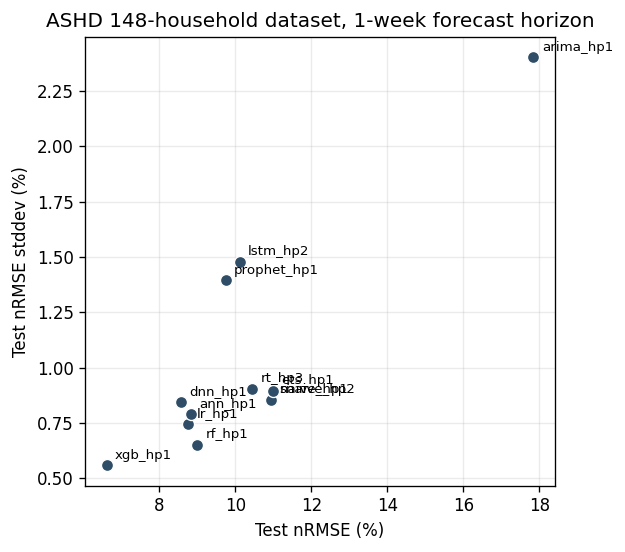

In [6]:
PAPER_MODEL_LABELS = {'m1_naive_hp1': 'naive_hp1', 'm2_snaive_hp2': 'snaive_hp2', 'm3_ets_hp1': 'ets_hp1', 'm4_arima_hp1': 'arima_hp1', 'm6_lr_hp1': 'lr_hp1', 'm7_ann_hp1': 'ann_hp1', 'm8_dnn_hp1': 'dnn_hp1', 'm9_rt_hp3': 'rt_hp3', 'm10_rf_hp1': 'rf_hp1', 'm13_lstm_hp2': 'lstm_hp2', 'm16_prophet_hp1': 'prophet_hp1', 'm17_xgb_hp1': 'xgb_hp1'}
scatter = combined_recap.loc[combined_recap["horizon_label"].astype(str).eq("1_week")].copy()
if scatter.empty:
    raise ValueError("Could not find ASHD 1-week rows in the combined horizon recap.")
scatter["model_label"] = scatter["model_name"].astype(str).map(PAPER_MODEL_LABELS).fillna(scatter["model_name"].astype(str))
scatter["test_nRMSE"] = pd.to_numeric(scatter["test_nRMSE"], errors="coerce")
scatter["test_nRMSE_stddev"] = pd.to_numeric(scatter["test_nRMSE_stddev"], errors="coerce")
if scatter[["test_nRMSE", "test_nRMSE_stddev"]].isna().any().any():
    raise ValueError("Scatterplot source contains missing nRMSE or nRMSE stddev values.")

fig, ax = plt.subplots(figsize=(5.3, 4.7))
ax.scatter(scatter["test_nRMSE"], scatter["test_nRMSE_stddev"], s=52, color="#2F4D67", edgecolor="white", linewidth=0.8, zorder=3)
for row in scatter.itertuples(index=False):
    ax.annotate(row.model_label, (row.test_nRMSE, row.test_nRMSE_stddev), xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.set_xlabel("Test nRMSE (%)")
ax.set_ylabel("Test nRMSE stddev (%)")
ax.set_title("ASHD 148-household dataset, 1-week forecast horizon")
ax.grid(alpha=0.25)
fig.tight_layout()
save_figure(fig, "paper_figure_ashd_fh10_nrmse_stddev_scatter.png")
plt.show()

In [7]:
for path in sorted(FIGURES_DIR.glob("*.png")):
    print(path)

<local path redacted>
<local path redacted>
<local path redacted>
<local path redacted>
